## 05 — Interpretability

เปิดกล่องดำของ models จาก Pillar 3/4 — ตอบคำถามว่า "model ตัดสินใจอย่างไร?"

## เป้าหมายของ notebook นี้

หลัง Pillar 4 เรารู้ว่า **model ทำงานได้แค่ไหน** (SupCon 0.697 RF, etc.)
แต่ไม่รู้ว่า **model ใช้อะไร** ในการแยกเครื่อง

Pillar 5 ตอบคำถามเชิง mechanism:
1. Token ไหน / pattern ไหนสำคัญสุดสำหรับแยก 4 เครื่อง?
2. เครื่องไหนสับสนกับเครื่องไหน — pattern ผิดอย่างไร?
3. Idiom ที่ทฤษฎีดนตรีไทยบอก — model จับได้จริงไหม?
4. Label-aware (SupCon) vs label-free (SSL-A) — ตัดสินใจต่างกันไหม?

## Why interpretability for Thai music

1. **Trust กับชุมชนดนตรี** — ครู/นักดนตรีต้องรู้ว่า model ใช้อะไร
2. **Validate ทฤษฎี** — เช่น "ระนาดเอก idiom = octave สูง + ลูกสบัด" — model confirm ไหม?
3. **หา bias** — model อาจ memorize piece แทน instrument idiom (Pillar 4 hint แล้ว)
4. **ปูทาง generation** — ต้องรู้ "อะไรทำให้เป็นระนาดเอก" ก่อน generate ทาง

## 4 Models ที่ analyze

| Model | Pillar 4 RF | บทบาทใน Pillar 5 |
|---|---|---|
| BiLSTM | 0.674 | Attention weights — เห็น token importance per window |
| CNN | 0.667 | Saliency maps (IG) — gradient-based attribution |
| SupCon-inst | 0.697 | Top-activating examples — label-aware contrastive |
| SSL-A | 0.651 | Top-activating + saliency — label-free perspective |

## โครงสร้าง 7 sections

| Section | หัวข้อ | Method |
|---|---|---|
| 1 | Setup + retrain models on full data | — |
| 2 | Hand-crafted feature importance | RF importance + permutation |
| 3 | Confusion + per-piece error analysis | softmax + kNN on embedding |
| 4 | Attention weights (BiLSTM) | extract via hook |
| 5 | Saliency maps (CNN + SSL-A) | Integrated Gradients (captum) |
| 6 | Top-activating examples × 3 models | softmax + nearest-to-centroid |
| 7 | Musicological synthesis | narrative + summary table |

## Important caveat

Section 5 ใช้ models ที่ retrain บน **full data** (ไม่ใช่ per-fold) — เพราะ:
- ต้องการ 1 representative model สำหรับ analyze behavior
- ไม่ใช่ generalization estimate (Pillar 4 ทำไปแล้ว — รายงานตัวเลขนั้น)

Pillar 5 = post-hoc analysis เพื่อเข้าใจ mechanism ไม่ใช่ benchmark

## Output

- `results/figures/feature_importance_*.png` (×2)
- `results/figures/confusion_4models.png`
- `results/figures/attention_*.png` (×2)
- `results/figures/saliency_*.png` (×3)
- `results/tables/top_activating_per_class.csv`
- `results/tables/interpretability_summary.csv`


## 1. Setup + retrain 4 models on full data

โหลด data, prepare vocab, retrain 4 models บน 819 windows ทั้งหมด

**ทำไม full data?**
- Section 2-7 = analyze model behavior, ไม่ใช่ evaluate performance
- ใช้ 1 model ที่ representative ที่สุด ต่อ architecture
- Pillar 4 รายงาน honest performance ด้วย per-fold CV แล้ว — Pillar 5 ไม่ทำซ้ำ

Models ที่ retrain:
- BiLSTM (256-dim, supervised CE)
- CNN (256-dim, supervised CE)
- SupCon-inst (256-dim, supervised contrastive) — train ด้วย triplet loss + instrument label
- SSL-A (256-dim, true SSL) — train ด้วย triplet loss + same-song positive


In [1]:
import sys
import os
import urllib.request
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/02_FindingInstrument')
else:
    PROJECT_ROOT = Path.cwd().parent

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# Thai font
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
FONT_PATH = Path('/content/Sarabun-Regular.ttf') if IN_COLAB else Path.home() / 'Sarabun-Regular.ttf'
if not FONT_PATH.exists():
    urllib.request.urlretrieve(FONT_URL, FONT_PATH)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont(str(FONT_PATH))
plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['axes.unicode_minus'] = False

# Reload utils
import importlib
import src.utils
importlib.reload(src.utils)

from src.utils import (
    load_notes, build_windows, compute_features_dataframe,
    set_seed, save_fig, save_table,
    INSTRUMENTS, PIECES, FEATURE_COLS,
    LOW_MARK, HIGH_MARK, SUSTAIN, NOTE_BASES,
)

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

set_seed(42)

# Load + prepare
df = load_notes()
df['section'] = df['section'].fillna('สาธุการ')
windows_df = build_windows(df, window_size=16, stride=8)
features_df = compute_features_dataframe(windows_df)

inst_to_idx = {inst: i for i, inst in enumerate(INSTRUMENTS)}
idx_to_inst = {i: inst for inst, i in inst_to_idx.items()}
windows_labels = features_df['instrument'].map(inst_to_idx).values

inst_colors = {
    'ขลุ่ย-ปี่':   '#4477aa',
    'ฆ้องวงใหญ่': '#ee7733',
    'ซออู้':       '#228833',
    'ระนาดเอก':    '#cc3366',
}

print(f"\n✓ data: {len(df):,} bars, {len(windows_df)} windows")
print(f"  Instruments: {INSTRUMENTS}")
print(f"  Pieces: {len(set(features_df['piece']))}")


Mounted at /content/drive
Device: cuda
GPU: Tesla T4

✓ data: 6,760 bars, 819 windows
  Instruments: ['ขลุ่ย-ปี่', 'ฆ้องวงใหญ่', 'ซออู้', 'ระนาดเอก']
  Pieces: 6


In [2]:
# Vocab + datasets + model classes — copy from notebook 04
PAD_ID = 0
UNK_ID = 1
all_tokens_in_data = sorted(set(t for tokens in windows_df['tokens'] for t in tokens))
token_to_id = {'<PAD>': PAD_ID, '<UNK>': UNK_ID}
for tok in all_tokens_in_data:
    token_to_id[tok] = len(token_to_id)
id_to_token = {v: k for k, v in token_to_id.items()}
VOCAB_SIZE = len(token_to_id)


def encode_tokens(tokens, vocab=token_to_id):
    return [vocab.get(t, UNK_ID) for t in tokens]


class NotationDataset(Dataset):
    def __init__(self, windows_subset, labels_subset):
        self.sequences = [encode_tokens(toks) for toks in windows_subset['tokens']]
        self.labels = labels_subset

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx], dtype=torch.long)
        length = len(seq)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, length, label


def collate_pad(batch):
    sequences, lengths, labels = zip(*batch)
    max_len = max(lengths)
    padded = torch.full((len(sequences), max_len), PAD_ID, dtype=torch.long)
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = seq
    return padded, torch.tensor(lengths), torch.stack(labels)


# Model classes
class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.context = nn.Parameter(torch.randn(dim))

    def forward(self, x, mask=None, return_weights=False):
        scores = (x @ self.context) / (x.size(-1) ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = F.softmax(scores, dim=1)
        out = (x * weights.unsqueeze(-1)).sum(dim=1)
        if return_weights:
            return out, weights
        return out


class ThaiCNN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(256, n_classes)

    def encode(self, x, lengths=None):
        x = self.embedding(x).transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        if lengths is not None:
            mask = (torch.arange(x.size(2), device=x.device)[None, :] < lengths[:, None])
            mask = mask.unsqueeze(1).float()
            x = x * mask
            x = x.sum(dim=2) / mask.sum(dim=2)
        else:
            x = x.mean(dim=2)
        return x

    def forward(self, x, lengths=None):
        emb = self.encode(x, lengths)
        return self.classifier(self.dropout(emb))


class ThaiBiLSTM(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
                 n_layers=2, n_classes=4, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0)
        self.attn = AttentionPool(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, n_classes)

    def encode(self, x, lengths, return_attention=False):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(),
                                                    batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        mask = (torch.arange(out.size(1), device=out.device)[None, :] < lengths[:, None])
        if return_attention:
            pooled, weights = self.attn(out, mask=mask, return_weights=True)
            return pooled, weights
        return self.attn(out, mask=mask)

    def forward(self, x, lengths):
        emb = self.encode(x, lengths)
        return self.classifier(self.dropout(emb))


class SSLCNN(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, proj_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(256)
        self.projection = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, proj_dim)
        )

    def encode(self, x, lengths=None):
        x = self.embedding(x).transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        if lengths is not None:
            mask = (torch.arange(x.size(2), device=x.device)[None, :] < lengths[:, None])
            mask = mask.unsqueeze(1).float()
            x = x * mask
            x = x.sum(dim=2) / mask.sum(dim=2)
        else:
            x = x.mean(dim=2)
        return x

    def forward(self, x, lengths=None):
        z = self.encode(x, lengths)
        z = self.projection(z)
        z = F.normalize(z, p=2, dim=1)
        return z


print(f"✓ Vocab: {VOCAB_SIZE} tokens")
print(f"✓ Model classes พร้อม: CNN, BiLSTM (with attention hook), SSLCNN (for SSL-A + SupCon-inst)")


✓ Vocab: 24 tokens
✓ Model classes พร้อม: CNN, BiLSTM (with attention hook), SSLCNN (for SSL-A + SupCon-inst)


In [3]:
# Peer indices + sampler — สำหรับ retrain SSL-A และ SupCon-inst
song_files            = features_df['song_file'].values
pieces_per_window     = features_df['piece'].values
instruments_per_window = features_df['instrument'].values

n = len(features_df)
same_song = [None] * n
same_inst_diff_piece = [None] * n

for i in range(n):
    my_song = song_files[i]
    my_piece = pieces_per_window[i]
    my_inst = instruments_per_window[i]
    same_song[i] = np.where(song_files == my_song)[0]
    same_inst_diff_piece[i] = np.where(
        (instruments_per_window == my_inst) & (pieces_per_window != my_piece)
    )[0]


def sample_triplet_full(anchor_idx, variant, n_neg=8, rng=None):
    # Sample triplet จาก full data (ไม่มี pool_mask) — สำหรับ retrain in Section 1
    if rng is None:
        rng = np.random
    my_song = song_files[anchor_idx]
    my_inst = instruments_per_window[anchor_idx]

    if variant == 'A':
        pos_pool = same_song[anchor_idx]
        pos_pool = pos_pool[pos_pool != anchor_idx]
        neg_mask = song_files != my_song
    elif variant == 'C':
        pos_pool = same_inst_diff_piece[anchor_idx]
        neg_mask = instruments_per_window != my_inst
    else:
        raise ValueError(f"Unknown variant: {variant}")

    if len(pos_pool) == 0:
        return None
    pos_idx = rng.choice(pos_pool)
    neg_candidates = np.where(neg_mask)[0]
    if len(neg_candidates) < n_neg:
        return None
    neg_idx = rng.choice(neg_candidates, size=n_neg, replace=False)
    return pos_idx, neg_idx


def triplet_loss_cosine(anchor, positive, negatives, margin=0.4):
    sim_pos = (anchor * positive).sum(dim=1)
    sim_neg = torch.einsum('bd,bnd->bn', anchor, negatives)
    losses = F.relu(margin - sim_pos.unsqueeze(1) + sim_neg)
    return losses.mean()


print(f"✓ Peer indices + triplet sampler พร้อม (n={n})")


✓ Peer indices + triplet sampler พร้อม (n=819)


In [4]:
# Retrain 4 models บน full data — สำหรับ analyze ใน Section 2-7
# Caveat: ตัวเลข accuracy ของ models เหล่านี้ = in-sample fit (Pillar 4 มี honest CV แล้ว)

def train_supervised_full(model_factory, epochs=25, lr=1e-3, batch_size=32, seed=42):
    set_seed(seed)
    ds = NotationDataset(windows_df, windows_labels)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_pad)

    model = model_factory().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in tqdm(range(epochs), desc='train', leave=False):
        for inputs, lengths, labels_ in loader:
            inputs, lengths, labels_ = inputs.to(device), lengths.to(device), labels_.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs, lengths), labels_)
            loss.backward()
            optimizer.step()

    return model


def train_ssl_full(variant, epochs=30, batch_size=32, n_neg=8, margin=0.4, lr=1e-3, seed=42):
    set_seed(seed)
    all_sequences = [encode_tokens(toks) for toks in windows_df['tokens']]
    model = SSLCNN(vocab_size=VOCAB_SIZE).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    rng = np.random.RandomState(seed)
    n_windows = len(windows_df)

    for epoch in tqdm(range(epochs), desc=f'ssl-{variant}', leave=False):
        model.train()
        anchor_order = rng.permutation(n_windows)
        for batch_start in range(0, n_windows, batch_size):
            anchor_idxs = anchor_order[batch_start:batch_start + batch_size]
            anchors_seq, pos_seq, neg_seqs = [], [], []
            for aidx in anchor_idxs:
                result = sample_triplet_full(aidx, variant, n_neg=n_neg, rng=rng)
                if result is None:
                    continue
                pos_idx, neg_idx = result
                anchors_seq.append(all_sequences[aidx])
                pos_seq.append(all_sequences[pos_idx])
                neg_seqs.append([all_sequences[ni] for ni in neg_idx])

            if len(anchors_seq) == 0:
                continue

            def pad_seqs(seqs):
                max_len = max(len(s) for s in seqs)
                padded = torch.full((len(seqs), max_len), PAD_ID, dtype=torch.long)
                lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
                for i, s in enumerate(seqs):
                    padded[i, :len(s)] = torch.tensor(s)
                return padded.to(device), lengths.to(device)

            anchor_pad, anchor_len = pad_seqs(anchors_seq)
            pos_pad, pos_len = pad_seqs(pos_seq)
            flat_negs = [s for grp in neg_seqs for s in grp]
            neg_pad, neg_len = pad_seqs(flat_negs)

            anchor_z   = model(anchor_pad, anchor_len)
            pos_z      = model(pos_pad, pos_len)
            neg_z_flat = model(neg_pad, neg_len)
            neg_z = neg_z_flat.view(len(anchors_seq), n_neg, -1)

            loss = triplet_loss_cosine(anchor_z, pos_z, neg_z, margin=margin)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return model


print("Retraining 4 models on full data...")

print("\n[1/4] CNN supervised CE...")
model_cnn = train_supervised_full(lambda: ThaiCNN())

print("\n[2/4] BiLSTM supervised CE...")
model_bilstm = train_supervised_full(lambda: ThaiBiLSTM())

print("\n[3/4] SupCon-inst (variant C, supervised contrastive)...")
model_supcon = train_ssl_full(variant='C')

print("\n[4/4] SSL-A (variant A, true SSL)...")
model_ssl_a = train_ssl_full(variant='A')

# Set all to eval mode
model_cnn.eval()
model_bilstm.eval()
model_supcon.eval()
model_ssl_a.eval()

print("\n✓ 4 models retrained on full data, set to eval mode")
print("  Models: model_cnn, model_bilstm, model_supcon, model_ssl_a")


Retraining 4 models on full data...

[1/4] CNN supervised CE...


train:   0%|          | 0/25 [00:00<?, ?it/s]


[2/4] BiLSTM supervised CE...


train:   0%|          | 0/25 [00:00<?, ?it/s]


[3/4] SupCon-inst (variant C, supervised contrastive)...


ssl-C:   0%|          | 0/30 [00:00<?, ?it/s]


[4/4] SSL-A (variant A, true SSL)...


ssl-A:   0%|          | 0/30 [00:00<?, ?it/s]


✓ 4 models retrained on full data, set to eval mode
  Models: model_cnn, model_bilstm, model_supcon, model_ssl_a


## 2. Hand-crafted feature importance

ตอบ: **"feature ไหนใน 7 features สำคัญสุดสำหรับแยกเครื่อง?"**

7 features จาก notebook 02:
- sustain_ratio — สัดส่วนของ token "-" (continuation/empty)
- low_oct_ratio — สัดส่วน octave ต่ำ (มี ฺ)
- mid_oct_ratio — สัดส่วน octave กลาง
- high_oct_ratio — สัดส่วน octave สูง (มี ํ)
- lukabad_density — สัดส่วนของ bars ที่มี ≥5 tokens (ลูกสบัด)
- paren_ratio — สัดส่วนของ bars ที่มีวงเล็บ
- transition_entropy — entropy ของ token transitions

### Methods

| Method | บอกอะไร |
|---|---|
| RF built-in (Gini) | feature ที่ช่วยลด impurity ใน decision tree |
| Permutation importance | feature ที่ shuffle แล้ว accuracy drop มาก |
| Per-class (one-vs-rest) | feature ที่สำคัญสำหรับแยกเครื่องนั้น vs ที่เหลือ |

Permutation importance reliable กว่า RF built-in ใน case ที่ features correlated


,feature,rf_builtin,permutation_mean,permutation_std
0,sustain_ratio,0.2281,0.3521,0.0131
1,low_oct_ratio,0.1675,0.3298,0.0117
2,mid_oct_ratio,0.1770,0.2027,0.0128
3,transition_entropy,0.2105,0.1723,0.0088
4,high_oct_ratio,0.1520,0.0921,0.0069
5,lukabad_density,0.0546,0.0741,0.0064
6,paren_ratio,0.0103,0.0084,0.0011


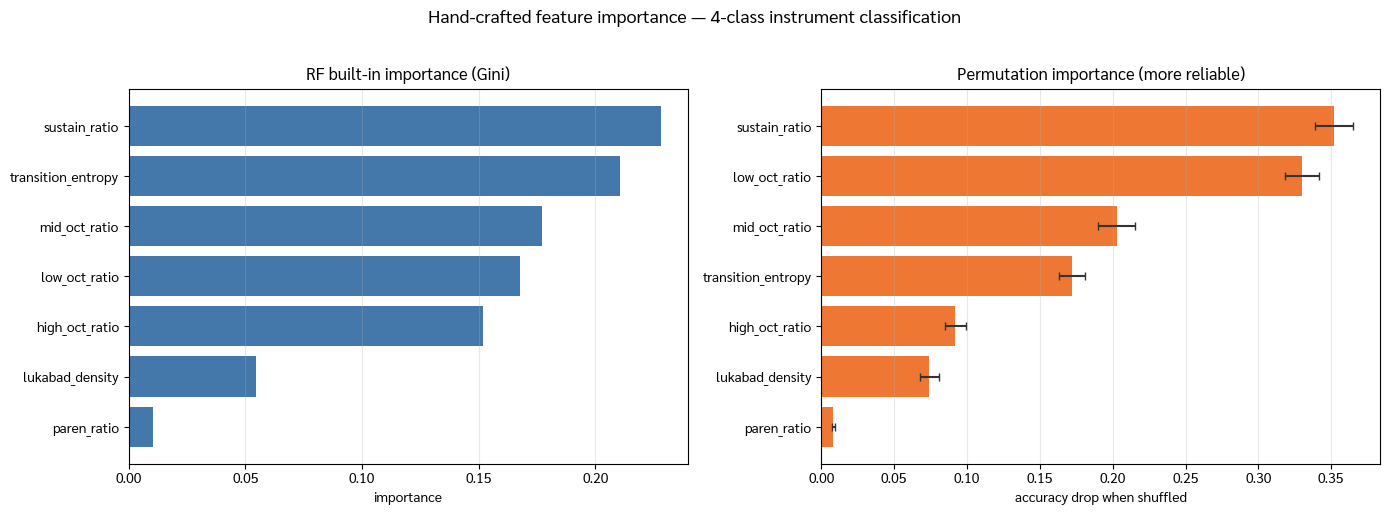


✓ saved → feature_importance.csv + feature_importance_global.png
  RF in-sample acc: 0.979


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

# RF + permutation importance (global)
X_hc = features_df[FEATURE_COLS].values
y = windows_labels

scaler = StandardScaler()
X_hc_scaled = scaler.fit_transform(X_hc)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_hc_scaled, y)

# Built-in importance
builtin_importance = rf.feature_importances_

# Permutation importance (more reliable)
perm = permutation_importance(rf, X_hc_scaled, y, n_repeats=20, random_state=42, n_jobs=-1)
perm_importance = perm.importances_mean
perm_std = perm.importances_std

importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'rf_builtin': builtin_importance,
    'permutation_mean': perm_importance,
    'permutation_std': perm_std,
}).sort_values('permutation_mean', ascending=False).reset_index(drop=True)

display(importance_df.round(4))
save_table(importance_df.round(4), 'feature_importance')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_sorted = importance_df.sort_values('rf_builtin', ascending=True)
axes[0].barh(imp_sorted['feature'], imp_sorted['rf_builtin'], color='#4477aa')
axes[0].set_title('RF built-in importance (Gini)', fontsize=12)
axes[0].set_xlabel('importance')
axes[0].grid(axis='x', alpha=0.3)

imp_sorted = importance_df.sort_values('permutation_mean', ascending=True)
axes[1].barh(imp_sorted['feature'], imp_sorted['permutation_mean'],
              xerr=imp_sorted['permutation_std'], color='#ee7733',
              error_kw={'ecolor': '#333', 'capsize': 3})
axes[1].set_title('Permutation importance (more reliable)', fontsize=12)
axes[1].set_xlabel('accuracy drop when shuffled')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Hand-crafted feature importance — 4-class instrument classification',
              fontsize=13, y=1.02)
plt.tight_layout()
save_fig('feature_importance_global')
plt.show()

print(f"\n✓ saved → feature_importance.csv + feature_importance_global.png")
print(f"  RF in-sample acc: {rf.score(X_hc_scaled, y):.3f}")


,sustain_ratio,low_oct_ratio,mid_oct_ratio,high_oct_ratio,lukabad_density,paren_ratio,transition_entropy
ขลุ่ย-ปี่,0.1214,0.0916,0.0758,0.1261,0.0493,0.0048,0.1376
ฆ้องวงใหญ่,0.2286,0.0980,0.0481,0.0224,0.0273,0.0036,0.0513
ซออู้,0.0649,0.1397,0.1652,0.0547,0.0374,0.0024,0.0907
ระนาดเอก,0.2177,0.2233,0.0686,0.0629,0.0299,0.0048,0.0971


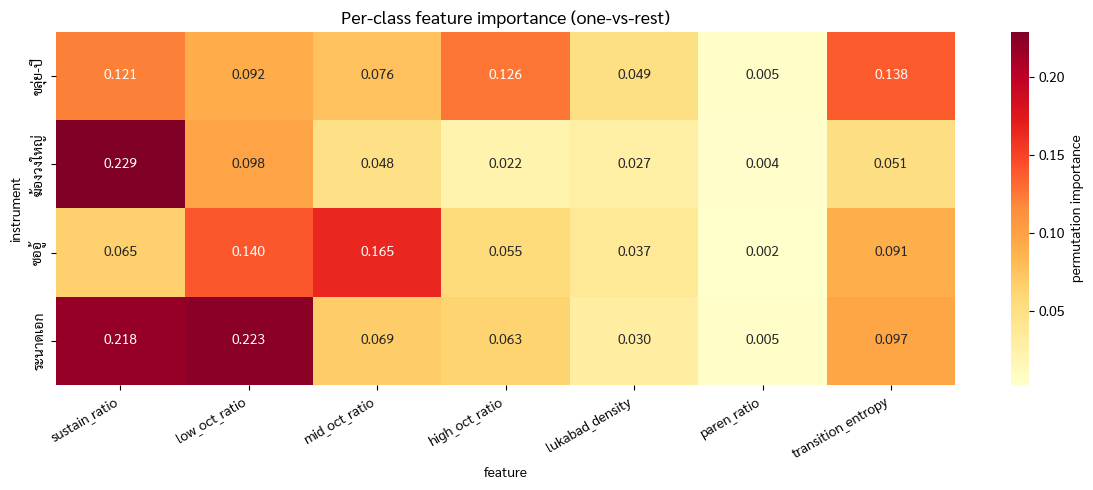


✓ saved → feature_importance_per_class.csv + .png


In [6]:
# Per-class feature importance — one-vs-rest binary RF
per_class_importance = np.zeros((len(INSTRUMENTS), len(FEATURE_COLS)))

for class_idx, inst in enumerate(INSTRUMENTS):
    y_binary = (y == class_idx).astype(int)
    rf_binary = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_binary.fit(X_hc_scaled, y_binary)
    perm_binary = permutation_importance(rf_binary, X_hc_scaled, y_binary,
                                           n_repeats=20, random_state=42, n_jobs=-1)
    per_class_importance[class_idx] = perm_binary.importances_mean

per_class_df = pd.DataFrame(per_class_importance,
                              index=INSTRUMENTS, columns=FEATURE_COLS).round(4)
display(per_class_df)
save_table(per_class_df.reset_index().rename(columns={'index': 'instrument'}),
            'feature_importance_per_class')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(per_class_df, annot=True, fmt='.3f', cmap='YlOrRd',
             cbar_kws={'label': 'permutation importance'}, ax=ax)
ax.set_title('Per-class feature importance (one-vs-rest)', fontsize=13)
ax.set_xlabel('feature')
ax.set_ylabel('instrument')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
save_fig('feature_importance_per_class')
plt.show()

print("\n✓ saved → feature_importance_per_class.csv + .png")


## 3. Confusion + per-piece error analysis

ตอบ: **"model สับสนเครื่องไหนกับเครื่องไหน? piece ไหนยาก?"**

### 4 models เทียบ confusion pattern

| Model | Prediction method |
|---|---|
| BiLSTM | softmax argmax |
| CNN | softmax argmax |
| SupCon-inst | nearest-centroid (centroid = mean embedding of training windows per class) |
| SSL-A | nearest-centroid (same as SupCon — แต่ centroid คำนวณจาก embedding ที่ train แบบ label-free) |

### Caveats

- ตัวเลขทั้งหมดใน Section 3 = in-sample (model เห็น data ทั้งหมดตอน train)
- ผลที่สนใจ = **pattern ของ confusion** ไม่ใช่ accuracy value
- Pillar 4 มี honest CV accuracy แล้ว

### คำถาม

- Confusion pattern ระหว่าง models เหมือนกันไหม?
- SSL-A กับ SupCon-inst (cosine-based) — สับสนต่างกันยังไงกับ softmax-based?
- Piece ไหนยากสำหรับทุก models?


In [7]:
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, accuracy_score


@torch.no_grad()
def predict_softmax(model, dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pad)
    preds, probs = [], []
    for inputs, lengths, _ in loader:
        inputs, lengths = inputs.to(device), lengths.to(device)
        logits = model(inputs, lengths)
        p = F.softmax(logits, dim=1)
        preds.append(logits.argmax(dim=1).cpu().numpy())
        probs.append(p.cpu().numpy())
    return np.concatenate(preds), np.concatenate(probs)


@torch.no_grad()
def extract_embeddings(model, dataset, batch_size=64):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pad)
    embs = []
    for inputs, lengths, _ in loader:
        inputs, lengths = inputs.to(device), lengths.to(device)
        emb = model.encode(inputs, lengths)
        embs.append(emb.cpu().numpy())
    return np.concatenate(embs)


def predict_nearest_centroid(embeddings_full, labels):
    # Compute class centroid, predict by cosine similarity
    embs_n = normalize(embeddings_full, axis=1)
    centroids = np.zeros((len(INSTRUMENTS), embs_n.shape[1]))
    for c in range(len(INSTRUMENTS)):
        mask = labels == c
        centroids[c] = embs_n[mask].mean(axis=0)
    centroids = normalize(centroids, axis=1)
    sims = embs_n @ centroids.T
    preds = sims.argmax(axis=1)
    return preds, sims, centroids


# Run predictions
ds_full = NotationDataset(windows_df, windows_labels)

print("Computing predictions for 4 models...")
preds_dict = {}
probs_dict = {}
embs_dict = {}
centroids_dict = {}

# Softmax models
preds_dict['bilstm'], probs_dict['bilstm'] = predict_softmax(model_bilstm, ds_full)
preds_dict['cnn'],    probs_dict['cnn']    = predict_softmax(model_cnn, ds_full)

# Nearest-centroid models
embs_dict['supcon'] = extract_embeddings(model_supcon, ds_full)
embs_dict['ssl_a']  = extract_embeddings(model_ssl_a, ds_full)

preds_dict['supcon'], probs_dict['supcon'], centroids_dict['supcon'] = \
    predict_nearest_centroid(embs_dict['supcon'], windows_labels)
preds_dict['ssl_a'],  probs_dict['ssl_a'],  centroids_dict['ssl_a']  = \
    predict_nearest_centroid(embs_dict['ssl_a'],  windows_labels)

# Accuracy summary
print(f"\n{'Model':<15s}  in-sample accuracy")
print("-" * 40)
for name in ['bilstm', 'cnn', 'supcon', 'ssl_a']:
    acc = accuracy_score(windows_labels, preds_dict[name])
    print(f"  {name:<13s}  {acc:.3f}")
print("\n  (in-sample = upper bound, Pillar 4 มี honest CV)")


Computing predictions for 4 models...

Model            in-sample accuracy
----------------------------------------
  bilstm         0.976
  cnn            0.955
  supcon         0.968
  ssl_a          0.784

  (in-sample = upper bound, Pillar 4 มี honest CV)


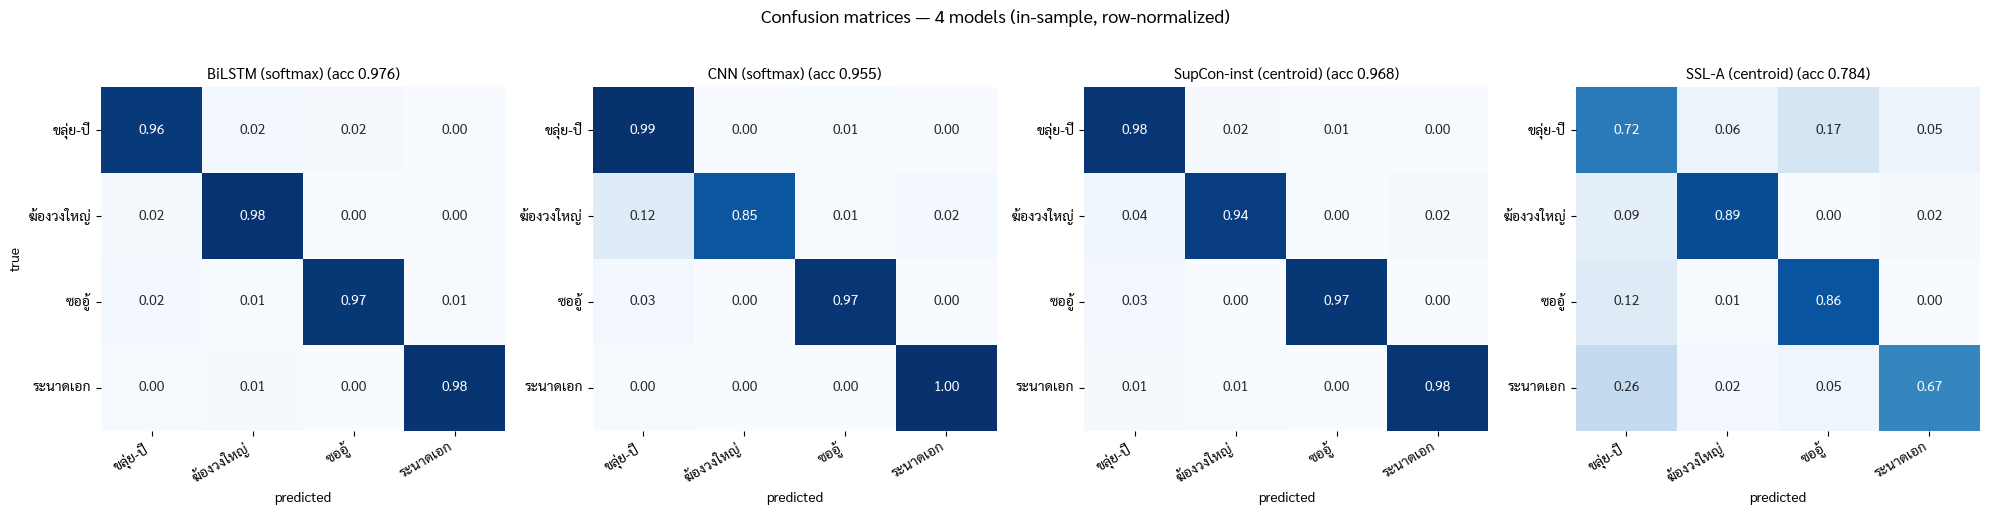


✓ saved → confusion_4models.png


In [8]:
# Confusion matrix × 4 models
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
model_order = ['bilstm', 'cnn', 'supcon', 'ssl_a']
model_titles = {
    'bilstm': 'BiLSTM (softmax)',
    'cnn':    'CNN (softmax)',
    'supcon': 'SupCon-inst (centroid)',
    'ssl_a':  'SSL-A (centroid)',
}

for ax, name in zip(axes, model_order):
    cm = confusion_matrix(windows_labels, preds_dict[name], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                 xticklabels=INSTRUMENTS, yticklabels=INSTRUMENTS,
                 cbar=False, ax=ax, vmin=0, vmax=1)
    acc = accuracy_score(windows_labels, preds_dict[name])
    ax.set_title(f'{model_titles[name]} (acc {acc:.3f})', fontsize=11)
    ax.set_xlabel('predicted')
    if name == 'bilstm':
        ax.set_ylabel('true')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.suptitle('Confusion matrices — 4 models (in-sample, row-normalized)',
              fontsize=13, y=1.02)
plt.tight_layout()
save_fig('confusion_4models')
plt.show()
print("\n✓ saved → confusion_4models.png")


,piece,n_windows,bilstm,cnn,supcon,ssl_a
0,กล่อมนารี,140,0.914,0.893,0.914,0.707
1,จีนขิมเล็ก,103,0.981,0.922,0.981,0.680
2,ตับต้นเพลงฉิ่ง,176,0.994,0.983,0.983,0.773
3,สาธุการ,216,0.995,0.995,0.986,0.907
4,แขกมอญบางช้าง,116,0.991,0.966,1.000,0.879
5,โหมโรงมหาฤกษ์,68,0.956,0.912,0.912,0.574


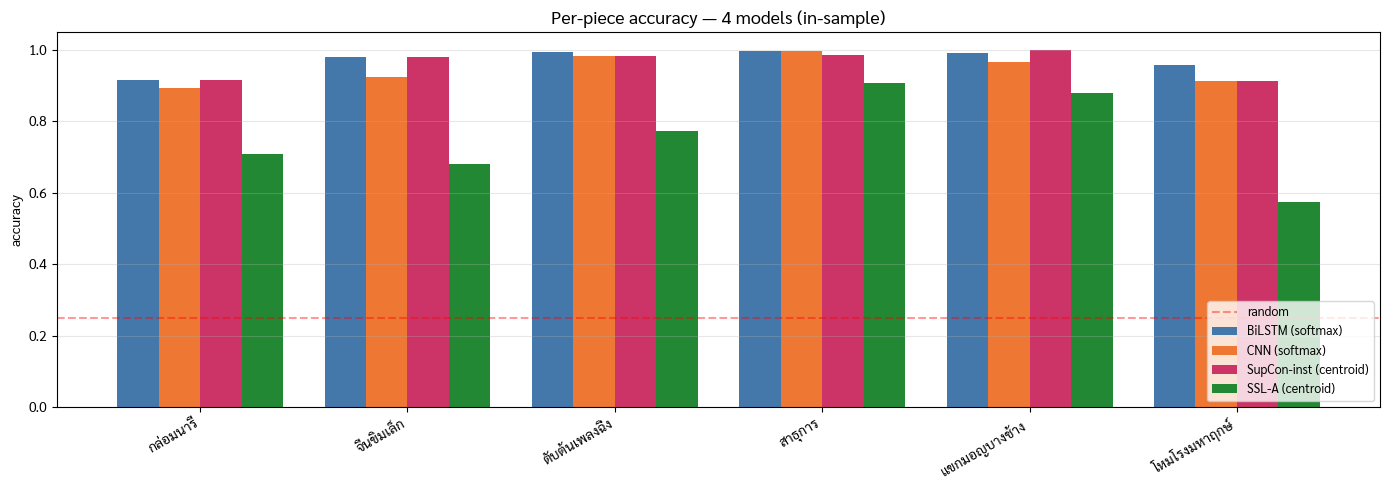


✓ saved → per_piece_accuracy.csv + .png


In [9]:
# Per-piece accuracy — เห็น piece bias ชัด
pieces_arr = features_df['piece'].values
piece_list = sorted(set(pieces_arr))

per_piece_data = []
for piece in piece_list:
    mask = pieces_arr == piece
    row = {'piece': piece, 'n_windows': mask.sum()}
    for name in model_order:
        row[name] = accuracy_score(windows_labels[mask], preds_dict[name][mask])
    per_piece_data.append(row)

per_piece_df = pd.DataFrame(per_piece_data)
display(per_piece_df.round(3))
save_table(per_piece_df.round(3), 'per_piece_accuracy')

# Plot — bar chart per piece × 4 models
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(piece_list))
width = 0.2
model_colors = {
    'bilstm': '#4477aa', 'cnn': '#ee7733',
    'supcon': '#cc3366', 'ssl_a': '#228833',
}

for i, name in enumerate(model_order):
    ax.bar(x + i * width, per_piece_df[name], width,
            label=model_titles[name], color=model_colors[name])

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(piece_list, rotation=30, ha='right')
ax.set_ylabel('accuracy')
ax.set_ylim(0, 1.05)
ax.axhline(0.25, color='red', linestyle='--', alpha=0.4, label='random')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Per-piece accuracy — 4 models (in-sample)', fontsize=13)
plt.tight_layout()
save_fig('per_piece_accuracy')
plt.show()

print("\n✓ saved → per_piece_accuracy.csv + .png")


In [10]:
# Top confused pairs — ดูว่าเครื่องไหนปนกับเครื่องไหนบ่อยสุด
print("Top confused pairs (averaged across 4 models):")
print("=" * 60)

pair_confusion = np.zeros((len(INSTRUMENTS), len(INSTRUMENTS)))
for name in model_order:
    cm = confusion_matrix(windows_labels, preds_dict[name], normalize='true')
    pair_confusion += cm
pair_confusion /= len(model_order)

# Off-diagonal pairs
pairs = []
for i in range(len(INSTRUMENTS)):
    for j in range(len(INSTRUMENTS)):
        if i != j:
            pairs.append({
                'true_class':      INSTRUMENTS[i],
                'predicted_class': INSTRUMENTS[j],
                'avg_confusion':   pair_confusion[i, j],
            })
pairs_df = pd.DataFrame(pairs).sort_values('avg_confusion', ascending=False)
display(pairs_df.round(3).head(8))
save_table(pairs_df.round(3), 'top_confused_pairs')

print(f"\nTop confusion: {pairs_df.iloc[0]['true_class']} → {pairs_df.iloc[0]['predicted_class']}  "
      f"({pairs_df.iloc[0]['avg_confusion']:.3f})")
print("\n✓ saved → top_confused_pairs.csv")


Top confused pairs (averaged across 4 models):


,true_class,predicted_class,avg_confusion
9,ระนาดเอก,ขลุ่ย-ปี่,0.069
3,ฆ้องวงใหญ่,ขลุ่ย-ปี่,0.067
1,ขลุ่ย-ปี่,ซออู้,0.050
6,ซออู้,ขลุ่ย-ปี่,0.050
0,ขลุ่ย-ปี่,ฆ้องวงใหญ่,0.024
2,ขลุ่ย-ปี่,ระนาดเอก,0.013
5,ฆ้องวงใหญ่,ระนาดเอก,0.013
11,ระนาดเอก,ซออู้,0.012



Top confusion: ระนาดเอก → ขลุ่ย-ปี่  (0.069)

✓ saved → top_confused_pairs.csv


## 4. Attention weights (BiLSTM)

ตอบ: **"ใน window หนึ่ง — token ไหนที่ model ให้ความสำคัญตอนตัดสินใจ?"**

### Method

BiLSTM ของเรามี `AttentionPool` ที่เรียน context vector แล้ว weighted-pool sequence:
- `scores[t] = (h_t · context) / sqrt(d)`
- `weights = softmax(scores)`
- `pooled = sum_t weights[t] · h_t`

`weights[t]` = ความสำคัญของ token ที่ position t

### Analyses

1. **Aggregate per class** — token type ไหน (e.g., "ด", "ม̇", "-") ได้ attention เฉลี่ยสูงสุดต่อเครื่อง
2. **Sample window visualization** — 4 windows (อย่างละเครื่อง) — heatmap ของ attention overlay บน tokens
3. **Note: attention != causal explanation** — แค่ correlate กับ model decision

### Caveat

BiLSTM อ่าน 2 ทิศ (forward + backward) — attention อาจไม่ตรงกับ "feature ที่ทำให้ classify" 100%
แต่ในทาง practice ใช้เป็น proxy ที่ดีพอสำหรับ token-level importance


In [11]:
@torch.no_grad()
def extract_attention_for_all(model, dataset, batch_size=32):
    # Extract attention weights สำหรับทุก window — return list ของ np.array length=L_i
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pad)
    all_weights = []
    model.eval()
    for inputs, lengths, _ in loader:
        inputs, lengths = inputs.to(device), lengths.to(device)
        _, weights = model.encode(inputs, lengths, return_attention=True)
        weights_np = weights.cpu().numpy()
        for i, L in enumerate(lengths.cpu().numpy()):
            all_weights.append(weights_np[i, :L])  # trim padding
    return all_weights


attention_weights = extract_attention_for_all(model_bilstm, ds_full)
print(f"✓ extracted attention สำหรับ {len(attention_weights)} windows")
print(f"  Example shapes: {[w.shape for w in attention_weights[:3]]}")


✓ extracted attention สำหรับ 819 windows
  Example shapes: [(69,), (68,), (64,)]


token category,sustain,low_oct,mid_oct,high_oct
ขลุ่ย-ปี่,0.0061,0.0181,0.0097,0.0372
ฆ้องวงใหญ่,0.0074,0.0264,0.0213,0.0133
ซออู้,0.0077,0.0235,0.0151,0.0242
ระนาดเอก,0.0079,0.0514,0.0100,0.0264


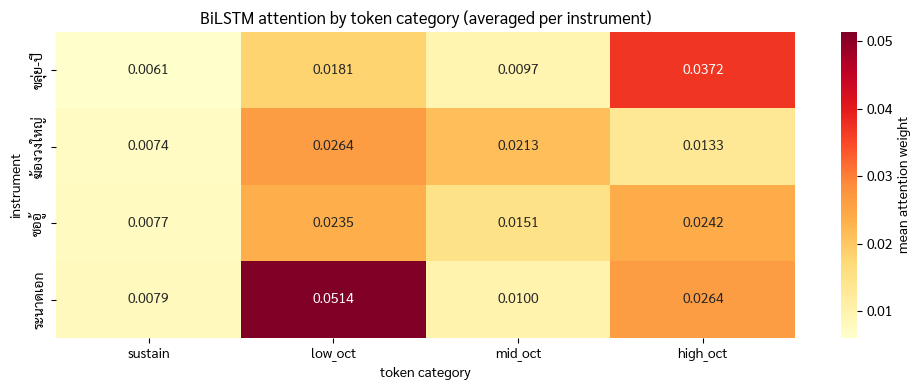


✓ saved → attention_per_class.csv + attention_aggregate.png


In [12]:
# Aggregate attention per class — token type ไหนได้ attention เฉลี่ยสูง

# Categorize tokens: pitch / sustain / high_oct / low_oct
def categorize_token(tok):
    if tok == SUSTAIN:
        return 'sustain'
    if HIGH_MARK in tok:
        return 'high_oct'
    if LOW_MARK in tok:
        return 'low_oct'
    return 'mid_oct'


token_categories = ['sustain', 'low_oct', 'mid_oct', 'high_oct']
attn_by_class = {inst: {cat: [] for cat in token_categories} for inst in INSTRUMENTS}

for window_idx, weights in enumerate(attention_weights):
    inst = features_df.iloc[window_idx]['instrument']
    tokens = windows_df.iloc[window_idx]['tokens']
    for tok, w in zip(tokens, weights):
        cat = categorize_token(tok)
        attn_by_class[inst][cat].append(w)

# Compute mean attention per category per class
attn_summary = pd.DataFrame({
    inst: {cat: np.mean(attn_by_class[inst][cat]) if len(attn_by_class[inst][cat]) > 0 else 0
            for cat in token_categories}
    for inst in INSTRUMENTS
}).T
attn_summary.columns.name = 'token category'
display(attn_summary.round(4))
save_table(attn_summary.reset_index().rename(columns={'index': 'instrument'}),
            'attention_per_class')

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(attn_summary, annot=True, fmt='.4f', cmap='YlOrRd',
             cbar_kws={'label': 'mean attention weight'}, ax=ax)
ax.set_title('BiLSTM attention by token category (averaged per instrument)', fontsize=12)
ax.set_xlabel('token category')
ax.set_ylabel('instrument')
plt.tight_layout()
save_fig('attention_aggregate')
plt.show()

print("\n✓ saved → attention_per_class.csv + attention_aggregate.png")


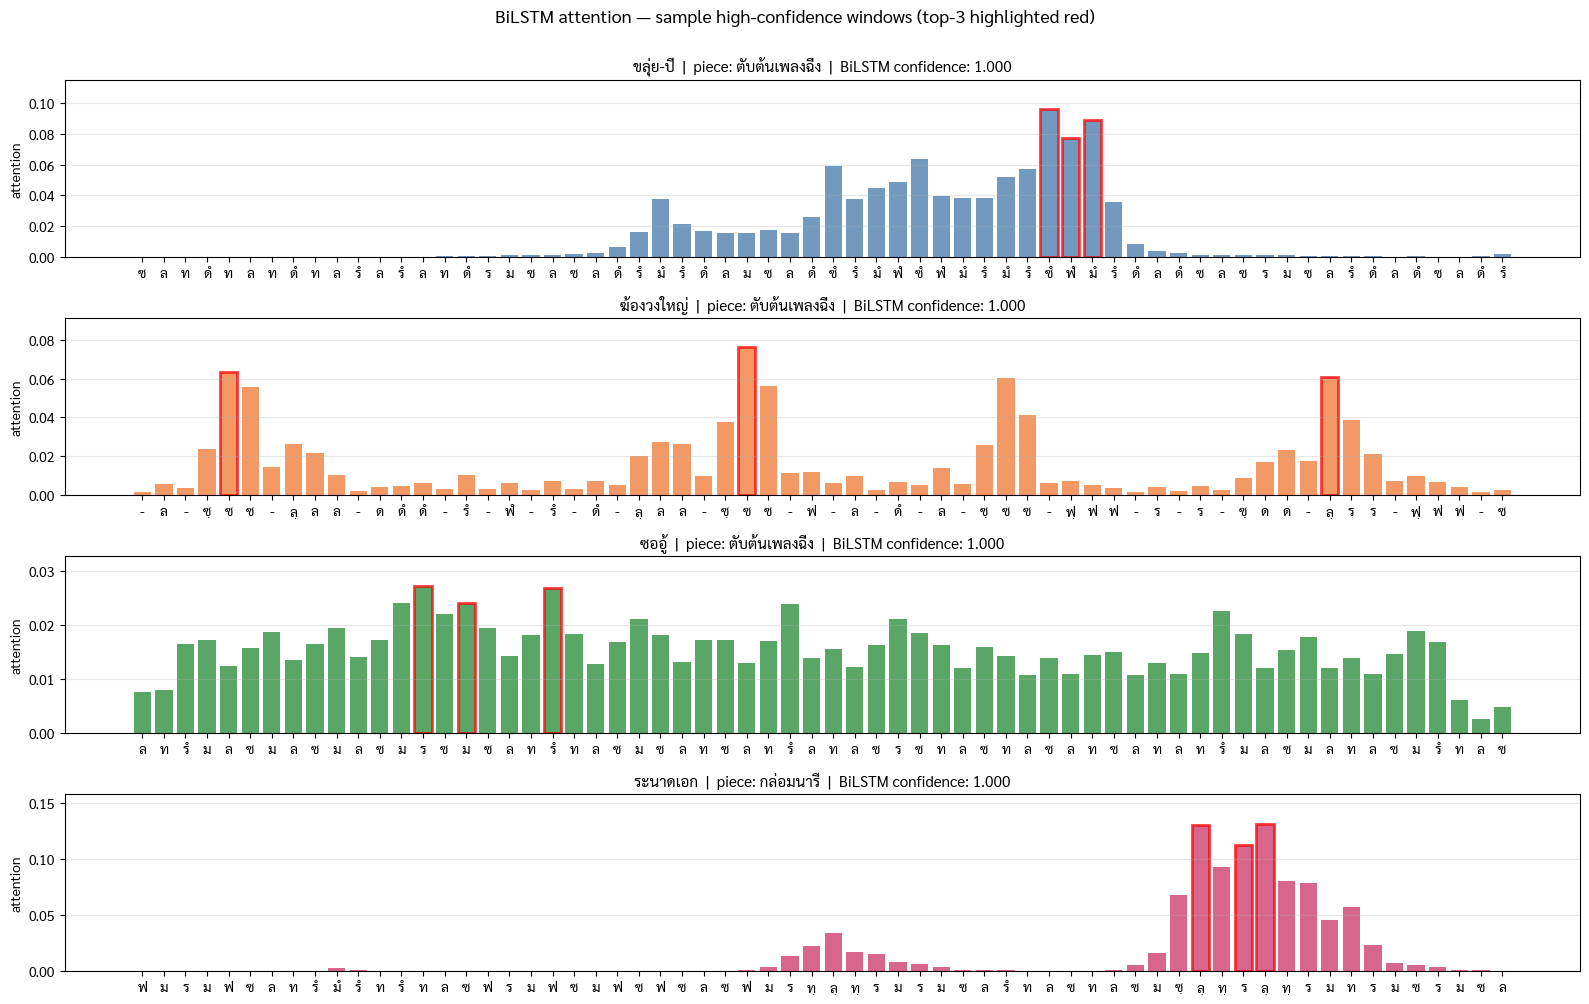


✓ saved → attention_samples.png  (4 sample windows)


In [13]:
# Sample window visualization — 4 windows อย่างละเครื่อง
# เลือก high-confidence windows (BiLSTM mostly correct + high prob)

samples_per_class = {}
for class_idx, inst in enumerate(INSTRUMENTS):
    # windows of this class, correctly predicted, with highest prob
    mask = (windows_labels == class_idx) & (preds_dict['bilstm'] == class_idx)
    candidate_idx = np.where(mask)[0]
    if len(candidate_idx) == 0:
        continue
    confidences = probs_dict['bilstm'][candidate_idx, class_idx]
    top = candidate_idx[np.argsort(-confidences)[:1]]
    samples_per_class[inst] = top[0]

# Plot 4 windows × 1 row each
fig, axes = plt.subplots(len(samples_per_class), 1, figsize=(16, len(samples_per_class) * 2.5))
if len(samples_per_class) == 1:
    axes = [axes]

for ax, (inst, w_idx) in zip(axes, samples_per_class.items()):
    tokens = windows_df.iloc[w_idx]['tokens']
    weights = attention_weights[w_idx]
    L = min(len(tokens), len(weights))
    tokens = tokens[:L]
    weights = weights[:L]

    piece = features_df.iloc[w_idx]['piece']
    conf = probs_dict['bilstm'][w_idx, inst_to_idx[inst]]

    # Bar plot of attention
    positions = np.arange(L)
    bars = ax.bar(positions, weights, color=inst_colors[inst], alpha=0.75)
    ax.set_xticks(positions)
    ax.set_xticklabels(tokens, fontsize=10, rotation=0)
    ax.set_ylabel('attention')
    ax.set_title(f"{inst}  |  piece: {piece}  |  BiLSTM confidence: {conf:.3f}", fontsize=11)
    ax.set_ylim(0, max(weights) * 1.2 if max(weights) > 0 else 1)
    ax.grid(axis='y', alpha=0.3)
    # Highlight top-3 attention positions
    top_idx = np.argsort(-weights)[:3]
    for ti in top_idx:
        bars[ti].set_edgecolor('red')
        bars[ti].set_linewidth(2)

plt.suptitle('BiLSTM attention — sample high-confidence windows (top-3 highlighted red)',
              fontsize=13, y=1.00)
plt.tight_layout()
save_fig('attention_samples')
plt.show()

print(f"\n✓ saved → attention_samples.png  ({len(samples_per_class)} sample windows)")


## 5. Saliency maps (CNN + SSL-A) — Integrated Gradients

ตอบ: **"token ไหนใน input ที่ส่งผลต่อ output (class prediction หรือ similarity-to-centroid) มากที่สุด?"**

### Method — Integrated Gradients (Sundararajan et al. 2017)

IG attribute output ของ model ไปยัง input โดย integrate gradients ระหว่าง baseline → input:

```
IG_i(x) = (x_i - x'_i) * ∫₀¹ ∂F(x' + α(x-x'))/∂x_i  dα
```

- baseline x' = embedding ของ PAD token
- 50 steps integration
- attribute per token position

**ทำไม IG ไม่ใช่ vanilla saliency:**
- Vanilla saliency = `∂F/∂x` ที่ input → noisy, saturation problems
- IG satisfies completeness axiom: sum(IG) = F(x) - F(baseline)
- More trustworthy สำหรับ interpretation

### Two targets

| Model | Target ที่ attribute |
|---|---|
| CNN | logit ของ true class — `model(x)[true_class]` |
| SSL-A | cosine similarity to class centroid — `cos(encode(x), centroid_true_class)` |

### Caveat

IG ทำงานบน continuous input (embedding vectors) ไม่ใช่ discrete tokens
→ attribute ที่ embedding layer แล้ว aggregate (sum across embed_dim) เป็น token-level score


In [14]:
try:
    from captum.attr import IntegratedGradients
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'captum'], check=True)
    from captum.attr import IntegratedGradients

# Compute SSL-A class centroids (จาก embeddings ที่ extract แล้ว)
ssl_a_embs_norm = normalize(embs_dict['ssl_a'], axis=1)
ssl_a_centroids = np.zeros((len(INSTRUMENTS), ssl_a_embs_norm.shape[1]))
for c in range(len(INSTRUMENTS)):
    mask = windows_labels == c
    ssl_a_centroids[c] = ssl_a_embs_norm[mask].mean(axis=0)
ssl_a_centroids = normalize(ssl_a_centroids, axis=1)
ssl_a_centroids_t = torch.tensor(ssl_a_centroids, dtype=torch.float32, device=device)


# Wrappers สำหรับ IG — model ต้อง output scalar (หรือ vector ที่ index ได้)

class CNNForIG(nn.Module):
    # Wrap CNN ให้ IG attribute embedding layer output
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, embeds, lengths):
        # embeds = embedding output (B, L, D) — IG inject ตรงนี้
        x = embeds.transpose(1, 2)
        x = F.relu(self.base.bn1(self.base.conv1(x)))
        x = F.relu(self.base.bn2(self.base.conv2(x)))
        x = F.relu(self.base.bn3(self.base.conv3(x)))
        x = F.relu(self.base.bn4(self.base.conv4(x)))
        mask = (torch.arange(x.size(2), device=x.device)[None, :] < lengths[:, None])
        mask = mask.unsqueeze(1).float()
        x = x * mask
        x = x.sum(dim=2) / mask.sum(dim=2)
        return self.base.classifier(x)


class SSLAForIG(nn.Module):
    # Wrap SSL-A ให้ output cosine similarity to chosen centroid
    def __init__(self, base_model, centroids):
        super().__init__()
        self.base = base_model
        self.centroids = centroids  # (n_classes, D)

    def forward(self, embeds, lengths, target_class):
        # target_class: scalar tensor (long) — class index for the batch
        x = embeds.transpose(1, 2)
        x = F.relu(self.base.bn1(self.base.conv1(x)))
        x = F.relu(self.base.bn2(self.base.conv2(x)))
        x = F.relu(self.base.bn3(self.base.conv3(x)))
        x = F.relu(self.base.bn4(self.base.conv4(x)))
        mask = (torch.arange(x.size(2), device=x.device)[None, :] < lengths[:, None])
        mask = mask.unsqueeze(1).float()
        x = x * mask
        x = x.sum(dim=2) / mask.sum(dim=2)  # (B, 256) — encode output
        x_norm = F.normalize(x, p=2, dim=1)
        # Cosine sim to centroid
        target_centroid = self.centroids[target_class]  # (D,)
        sim = (x_norm * target_centroid).sum(dim=1)
        return sim.unsqueeze(1)  # (B, 1) for IG compatibility


cnn_wrapper = CNNForIG(model_cnn).to(device).eval()
ssl_a_wrapper = SSLAForIG(model_ssl_a, ssl_a_centroids_t).to(device).eval()

print("✓ captum + IG wrappers พร้อม")
print("  CNN target: logit ของ true class")
print("  SSL-A target: cos(encode(x), centroid ของ true class)")


✓ captum + IG wrappers พร้อม
  CNN target: logit ของ true class
  SSL-A target: cos(encode(x), centroid ของ true class)


In [15]:
# Compute IG for sample windows — 1 high-confidence window per instrument (4 total)
# CNN attribute logit; SSL-A attribute cosine-to-centroid

# Reuse samples from Section 4
sample_w_idx = list(samples_per_class.values())

ig_cnn = IntegratedGradients(cnn_wrapper)
ig_ssl_a = IntegratedGradients(ssl_a_wrapper)


def compute_ig_for_window(model_wrapper, ig, w_idx, target_class, model_type='cnn'):
    # Compute IG attribution for a single window — return token-level scores
    tokens = windows_df.iloc[w_idx]['tokens']
    seq = encode_tokens(tokens)
    L = len(seq)
    input_ids = torch.tensor([seq], dtype=torch.long).to(device)
    lengths = torch.tensor([L], dtype=torch.long).to(device)

    # Get embedding output (need to attribute at embedding layer)
    embed_layer = model_wrapper.base.embedding
    embeds = embed_layer(input_ids)  # (1, L, D)
    baseline_ids = torch.full_like(input_ids, PAD_ID)
    baseline_embeds = embed_layer(baseline_ids)

    if model_type == 'cnn':
        attr = ig.attribute(inputs=embeds, baselines=baseline_embeds,
                             additional_forward_args=(lengths,),
                             target=target_class, n_steps=50,
                             internal_batch_size=10)
    else:  # ssl_a
        target_class_t = torch.tensor([target_class], device=device)
        attr = ig.attribute(inputs=embeds, baselines=baseline_embeds,
                             additional_forward_args=(lengths, target_class_t),
                             target=0, n_steps=50,
                             internal_batch_size=10)

    # Aggregate across embedding dim → token-level score (sum abs)
    attr_np = attr[0].detach().cpu().numpy()  # (L, D)
    token_scores = np.abs(attr_np).sum(axis=1)
    return tokens, token_scores


# Compute for all sample windows
ig_results = {}
for inst, w_idx in samples_per_class.items():
    class_idx = inst_to_idx[inst]
    print(f"  IG for {inst} (window {w_idx})...")
    tokens, cnn_scores = compute_ig_for_window(cnn_wrapper, ig_cnn, w_idx, class_idx, 'cnn')
    _,      ssl_scores = compute_ig_for_window(ssl_a_wrapper, ig_ssl_a, w_idx, class_idx, 'ssl_a')
    ig_results[inst] = {
        'window_idx': w_idx,
        'tokens': tokens,
        'cnn_scores': cnn_scores,
        'ssl_a_scores': ssl_scores,
    }

print(f"\n✓ IG computed for {len(ig_results)} sample windows × 2 models")


  IG for ขลุ่ย-ปี่ (window 61)...
  IG for ฆ้องวงใหญ่ (window 249)...
  IG for ซออู้ (window 483)...
  IG for ระนาดเอก (window 597)...

✓ IG computed for 4 sample windows × 2 models


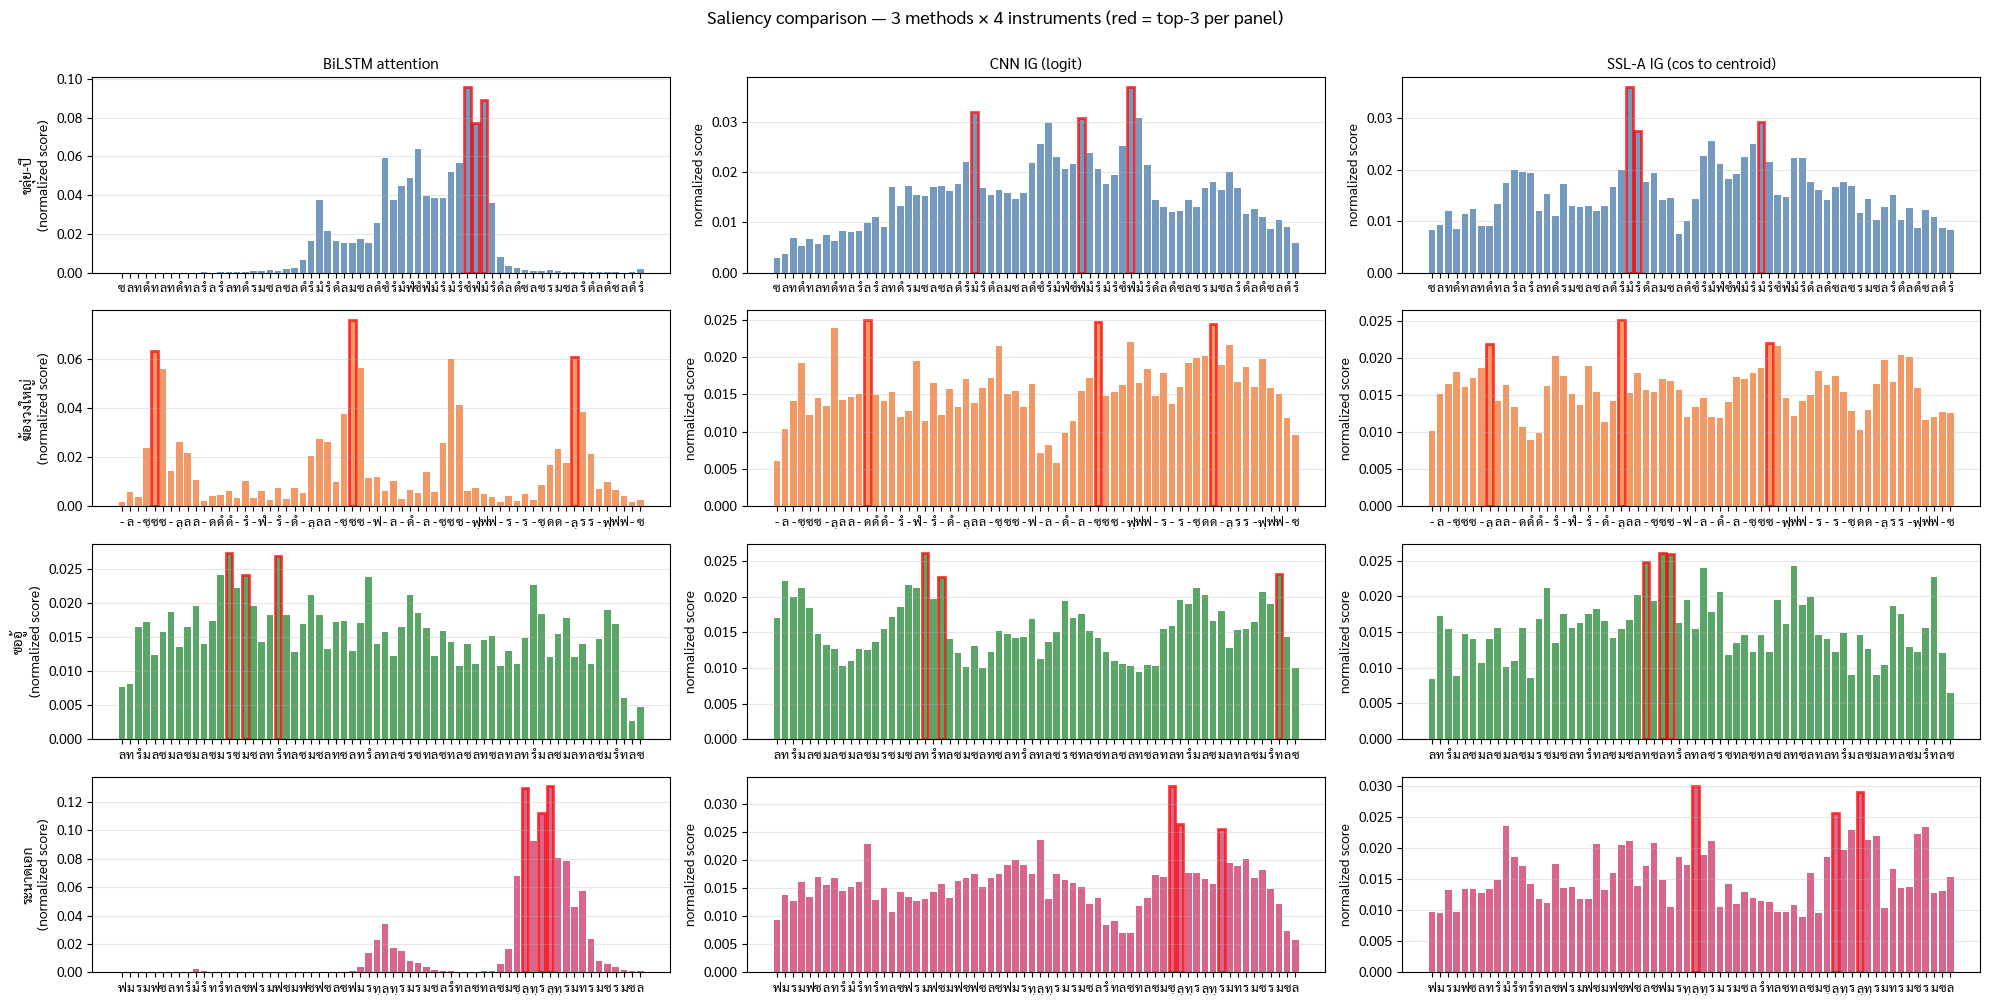


✓ saved → saliency_comparison.png


In [16]:
# Side-by-side comparison: CNN IG vs SSL-A IG vs BiLSTM attention
# 4 instruments × 3 methods stacked

fig, axes = plt.subplots(len(ig_results), 3, figsize=(20, len(ig_results) * 2.5))
if len(ig_results) == 1:
    axes = axes.reshape(1, -1)

method_titles = ['BiLSTM attention', 'CNN IG (logit)', 'SSL-A IG (cos to centroid)']

for row, (inst, data) in enumerate(ig_results.items()):
    w_idx = data['window_idx']
    tokens = data['tokens']
    L = len(tokens)

    bilstm_attn = attention_weights[w_idx][:L]
    cnn_scores = data['cnn_scores']
    ssl_scores = data['ssl_a_scores']

    # Normalize each for visual comparability (sum to 1)
    def normalize_scores(arr):
        s = arr.sum()
        return arr / s if s > 0 else arr

    score_lists = [
        normalize_scores(bilstm_attn),
        normalize_scores(cnn_scores),
        normalize_scores(ssl_scores),
    ]

    for col, (scores, title) in enumerate(zip(score_lists, method_titles)):
        ax = axes[row, col]
        positions = np.arange(L)
        bars = ax.bar(positions, scores, color=inst_colors[inst], alpha=0.75)
        ax.set_xticks(positions)
        ax.set_xticklabels(tokens, fontsize=9, rotation=0)
        ax.set_ylabel('normalized score')
        if row == 0:
            ax.set_title(title, fontsize=11)
        if col == 0:
            ax.set_ylabel(f'{inst}\n(normalized score)', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        # Highlight top-3
        top_idx = np.argsort(-scores)[:3]
        for ti in top_idx:
            bars[ti].set_edgecolor('red')
            bars[ti].set_linewidth(2)

plt.suptitle('Saliency comparison — 3 methods × 4 instruments (red = top-3 per panel)',
              fontsize=13, y=1.00)
plt.tight_layout()
save_fig('saliency_comparison')
plt.show()

print("\n✓ saved → saliency_comparison.png")


## 6. Top-activating examples per class — 3 models

ตอบ: **"window แบบไหนที่ model มั่นใจมากสุดว่าเป็นเครื่องนั้น?"**

### Method per model

| Model | Ranking signal |
|---|---|
| BiLSTM (supervised CE) | softmax probability ของ class นั้น |
| SupCon-inst (supervised contrastive) | cosine similarity to class centroid |
| SSL-A (true SSL) | cosine similarity to class centroid (same method as SupCon, แต่ centroid คำนวณจาก SSL embedding) |

### ทำไม top-K

- Top-5 windows ต่อ class ต่อ model = 5 × 4 × 3 = 60 examples
- Window ที่ model มั่นใจสุด = stereotypical example ของ class นั้น
- เปรียบเทียบ across models → เห็นว่า 3 paradigms มอง "stereotype" เหมือนกันไหม

### Qualitative interpretation

หลังได้ top windows — ดู:
- Tokens ใน window — มี pattern อะไร?
- Piece ที่มา — มาจาก piece หลากหลายหรือ piece เดียว?
- Section / start_bar — มาจากท่อน intro หรือ middle?

ถ้า top windows มาจาก piece เดียวกัน → model จับ piece-specific pattern (= piece bias)
ถ้ามาจากหลาย pieces → model จับ instrument idiom จริง


In [17]:
# Top-K per class — BiLSTM (softmax probability)
TOP_K = 5

def get_top_k_bilstm(class_idx, k=TOP_K):
    probs = probs_dict['bilstm'][:, class_idx]
    top_idx = np.argsort(-probs)[:k]
    return top_idx, probs[top_idx]


print(f"Top-{TOP_K} windows per instrument — BiLSTM (softmax probability)")
print("=" * 90)

bilstm_top = []
for class_idx, inst in enumerate(INSTRUMENTS):
    top_idx, top_probs = get_top_k_bilstm(class_idx)
    print(f"\n[{inst}]")
    for rank, (w_idx, prob) in enumerate(zip(top_idx, top_probs), 1):
        tokens = ' '.join(windows_df.iloc[w_idx]['tokens'])
        piece = features_df.iloc[w_idx]['piece']
        true_inst = features_df.iloc[w_idx]['instrument']
        flag = '✓' if true_inst == inst else f'✗ (actual: {true_inst})'
        print(f"  #{rank}  prob={prob:.3f}  piece={piece:<18s}  {flag}")
        print(f"        tokens: {tokens}")
        bilstm_top.append({
            'model': 'bilstm',
            'predicted_class': inst,
            'rank': rank,
            'window_idx': w_idx,
            'piece': piece,
            'actual_instrument': true_inst,
            'confidence': prob,
            'tokens': tokens,
        })


Top-5 windows per instrument — BiLSTM (softmax probability)

[ขลุ่ย-ปี่]
  #1  prob=1.000  piece=ตับต้นเพลงฉิ่ง      ✓
        tokens: ซ ล ท ดํ ท ล ท ดํ ท ล รํ ล รํ ล ท ดํ ร ม ซ ล ซ ล ดํ รํ มํ รํ ดํ ล ม ซ ล ดํ ซํ รํ มํ ฟํ ซํ ฟํ มํ รํ มํ รํ ซํ ฟํ มํ รํ ดํ ล ดํ ซ ล ซ ร ม ซ ล รํ ดํ ล ดํ ซ ล ดํ รํ
  #2  prob=1.000  piece=สาธุการ             ✓
        tokens: รํ ล ล ล รํ ท ท ท รํ มํ รํ ท ล ท รํ มํ ล ท รํ ล ท ล ฟ ม ล ท ล ทฺ ร ม ร ทฺ ฟ ท ล ท รํ ท มํ รํ ฟํ มํ ลํ มํ ฟํ รํ มํ ฟํ รํ ล ล ล รํ ท ล - ฟ - ม ล ร ฟ ม ร
  #3  prob=1.000  piece=โหมโรงมหาฤกษ์       ✓
        tokens: - - - - - - - - - - - รํ - - - ท - - - - ล ซ ล ท รํ ท รํ ล - ท - รํ - - - - ล ท รํ มํ ซํ ลํ ซํ รํ ซํ มํ รํ ท ท ท รํ ท รํ ล - ทฺ ล ท รํ มํ ซ ร - ม
  #4  prob=1.000  piece=กล่อมนารี           ✓
        tokens: ซ ด ร ม ฟ ซ - ฟ ด ฟ ม ฟ ร ม ด ร ดํ ล ซ ม ล ซ ม ร มํ รํ ซํ ฟํ มํ รํ ดํ ท - - ล ท รํ มํ รํ ท รํ ล รํ ท รํ มํ รํ ท มํ รํ ซํ มํ ซํ รํ มํ ท รํ ท มํ รํ มํ ท รํ ล
  #5  prob=1.000  piece=โหมโรงมหาฤกษ์       ✓
        tokens: - - 

In [18]:
# Top-K per class — SupCon-inst (cosine to class centroid)
sims_supcon = probs_dict['supcon']  # (N, n_classes) — similarity scores

print(f"\nTop-{TOP_K} windows per instrument — SupCon-inst (cos similarity to centroid)")
print("=" * 90)

supcon_top = []
for class_idx, inst in enumerate(INSTRUMENTS):
    sims = sims_supcon[:, class_idx]
    top_idx = np.argsort(-sims)[:TOP_K]
    top_sims = sims[top_idx]
    print(f"\n[{inst}]")
    for rank, (w_idx, sim) in enumerate(zip(top_idx, top_sims), 1):
        tokens = ' '.join(windows_df.iloc[w_idx]['tokens'])
        piece = features_df.iloc[w_idx]['piece']
        true_inst = features_df.iloc[w_idx]['instrument']
        flag = '✓' if true_inst == inst else f'✗ (actual: {true_inst})'
        print(f"  #{rank}  cos={sim:.3f}  piece={piece:<18s}  {flag}")
        print(f"        tokens: {tokens}")
        supcon_top.append({
            'model': 'supcon_inst',
            'predicted_class': inst,
            'rank': rank,
            'window_idx': w_idx,
            'piece': piece,
            'actual_instrument': true_inst,
            'confidence': sim,
            'tokens': tokens,
        })



Top-5 windows per instrument — SupCon-inst (cos similarity to centroid)

[ขลุ่ย-ปี่]
  #1  cos=0.995  piece=สาธุการ             ✓
        tokens: - - - ล รํ - ล ซ ม - ร - ม - - ซ ล - ท - รํ - ท - ล - - - ซ - - ล ซ ม ล ท ดํ รํ ซํ มํ รํ ดํ ท ดํ รํ มํ รํ ดํ ท ล ม ฟ ล ท รํ ท ล - ฟ - ทฺ ท ล ฟ ม ร
  #2  cos=0.994  piece=แขกมอญบางช้าง       ✓
        tokens: - - ซ ม - ม ม ม ซ ล ซ ร ซ ม ร ด ร ซ ล ท ดํ มํ รํ ดํ ซ ร ซ มํ รํ ดํ ท ล รํ มํ รํ ท รํ ท ล ซ ล ท รํ ซํ ฟํ มํ รํ ท - รํ - ซํ มํ - รํ - ท - - - ล ท - ล ซ
  #3  cos=0.993  piece=สาธุการ             ✓
        tokens: - - - ล รํ - ล ซ ม - ร - ม - - ซ ล - ท - รํ - ท - ล - - - ซ - - ล ซ ม ล ท ดํ รํ ซํ มํ รํ ดํ ท ดํ รํ มํ รํ ดํ ท ล ม ฟ ล ท รํ ท ล - ฟ - ทฺ ท ล ท ดํ รํ
  #4  cos=0.992  piece=กล่อมนารี           ✓
        tokens: - - - ม - ซ ซ ซ - - - ล - ซ ซ ซ - มํ - รํ - ดํ - ท ล ซ ล ท - ดํ - รํ - - - ดํ - ดํ - ดํ - ดํ - ร ซํ มํ รํ ดํ - มํ - ซํ - มํ - รํ ซํ มํ รํ ดํ มํ รํ ดํ ท
  #5  cos=0.992  piece=แขกมอญบางช้าง       ✓
        tokens: - - - ม - ซ

In [19]:
# Top-K per class — SSL-A (cosine to class centroid)
sims_ssl_a = probs_dict['ssl_a']

print(f"\nTop-{TOP_K} windows per instrument — SSL-A (cos similarity to centroid)")
print("=" * 90)

ssl_a_top = []
for class_idx, inst in enumerate(INSTRUMENTS):
    sims = sims_ssl_a[:, class_idx]
    top_idx = np.argsort(-sims)[:TOP_K]
    top_sims = sims[top_idx]
    print(f"\n[{inst}]")
    for rank, (w_idx, sim) in enumerate(zip(top_idx, top_sims), 1):
        tokens = ' '.join(windows_df.iloc[w_idx]['tokens'])
        piece = features_df.iloc[w_idx]['piece']
        true_inst = features_df.iloc[w_idx]['instrument']
        flag = '✓' if true_inst == inst else f'✗ (actual: {true_inst})'
        print(f"  #{rank}  cos={sim:.3f}  piece={piece:<18s}  {flag}")
        print(f"        tokens: {tokens}")
        ssl_a_top.append({
            'model': 'ssl_a',
            'predicted_class': inst,
            'rank': rank,
            'window_idx': w_idx,
            'piece': piece,
            'actual_instrument': true_inst,
            'confidence': sim,
            'tokens': tokens,
        })

# Combine and save
all_top = pd.DataFrame(bilstm_top + supcon_top + ssl_a_top)
save_table(all_top.round(3), 'top_activating_per_class')
print(f"\n\n✓ saved → top_activating_per_class.csv  ({len(all_top)} rows)")



Top-5 windows per instrument — SSL-A (cos similarity to centroid)

[ขลุ่ย-ปี่]
  #1  cos=0.971  piece=แขกมอญบางช้าง       ✓
        tokens: ท ล ท ซ ล ท ดํ รํ - ดํ - รํ ฟํ มํ รํ ดํ - ซ - ร - ม ซ ฟ ซ - ล ท - ล - ท - ดํ - รํ - - - ม - ม ม ม ซ ล ซ ร ซ ม ร ด ซ ร ซ ล รํ ล ท ดํ ท ดํ รํ ดํ ท ล ซ ม
  #2  cos=0.961  piece=กล่อมนารี           ✗ (actual: ซออู้)
        tokens: - - ร ม ฟ ซ ล ท - - รํ มํ รํ ดํ ท ล - - รํ มํ รํ ท ล ซ ท ล รํ ท - - - - รํ ล รํ ดํ ท ล ซ ม ซ ล ท ซ ล ท - ล - ร - ซ ท ล ซ ล ท - รํ - ท - ล - ซ
  #3  cos=0.959  piece=แขกมอญบางช้าง       ✓
        tokens: - - ซ ม - ม ม ม ซ ล ซ ร ซ ม ร ด ร ซ ล ท ดํ มํ รํ ดํ ซ ร ซ มํ รํ ดํ ท ล รํ มํ รํ ท รํ ท ล ซ ล ท รํ ซํ ฟํ มํ รํ ท - รํ - ซํ มํ - รํ - ท - - - ล ท - ล ซ
  #4  cos=0.954  piece=แขกมอญบางช้าง       ✓
        tokens: - - - ม - ซ ซ ซ - - - ล - ซ ซ ซ ล ท รํ มํ ร ม ซ ล ท ล ซ ม ซ ล - ซ ท ล ท ซ ล ท ดํ รํ - ดํ - รํ ฟํ มํ รํ ดํ - ซ - ร - ม ซ ฟ ซ - ล ท - ล - ท - ดํ - รํ
  #5  cos=0.947  piece=แขกมอญบางช้าง       ✓
        tokens: - - - ม 

Number of unique pieces in top-5 (max=5, low=piece bias):


model,bilstm,ssl_a,supcon_inst
instrument,,,
ขลุ่ย-ปี่,4,2,3
ฆ้องวงใหญ่,2,3,2
ซออู้,2,1,5
ระนาดเอก,2,2,2



Number of correctly-classified windows in top-5 (max=5):


model,bilstm,ssl_a,supcon_inst
instrument,,,
ขลุ่ย-ปี่,5,4,5
ฆ้องวงใหญ่,5,5,5
ซออู้,5,5,5
ระนาดเอก,5,5,5


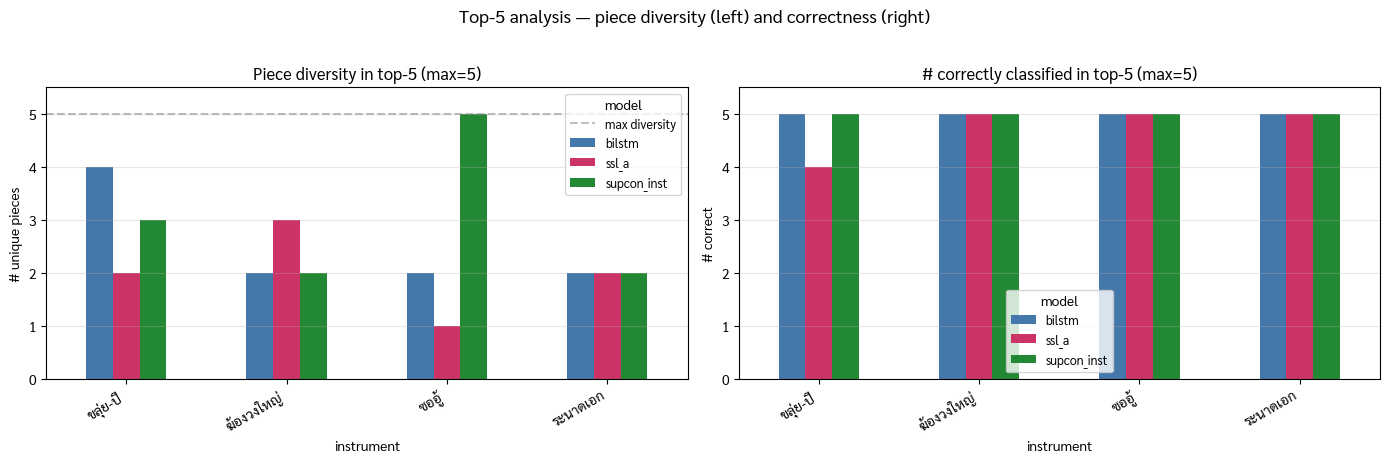


✓ saved → top_activating_comparison.png


In [20]:
# 3-way comparison — piece diversity ใน top-K
# Question: top windows ของแต่ละ model มาจาก piece หลากหลายหรือ piece เดียว?
# (น้อย = piece bias สูง, มาก = capture instrument idiom ดี)

piece_diversity = []
for model_name in ['bilstm', 'supcon_inst', 'ssl_a']:
    for inst in INSTRUMENTS:
        rows = all_top[(all_top['model'] == model_name) & (all_top['predicted_class'] == inst)]
        n_unique_pieces = rows['piece'].nunique()
        n_correct = (rows['actual_instrument'] == inst).sum()
        piece_diversity.append({
            'model': model_name,
            'instrument': inst,
            'unique_pieces_in_top5': n_unique_pieces,
            'correct_in_top5': n_correct,
        })

div_df = pd.DataFrame(piece_diversity)
div_pivot = div_df.pivot(index='instrument', columns='model', values='unique_pieces_in_top5')
print("Number of unique pieces in top-5 (max=5, low=piece bias):")
display(div_pivot)

correct_pivot = div_df.pivot(index='instrument', columns='model', values='correct_in_top5')
print("\nNumber of correctly-classified windows in top-5 (max=5):")
display(correct_pivot)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

div_pivot.plot(kind='bar', ax=axes[0], color=['#4477aa', '#cc3366', '#228833'])
axes[0].set_title('Piece diversity in top-5 (max=5)', fontsize=12)
axes[0].set_ylabel('# unique pieces')
axes[0].axhline(5, color='gray', linestyle='--', alpha=0.5, label='max diversity')
axes[0].set_ylim(0, 5.5)
axes[0].legend(title='model', fontsize=9)
axes[0].set_xticklabels(div_pivot.index, rotation=30, ha='right')
axes[0].grid(axis='y', alpha=0.3)

correct_pivot.plot(kind='bar', ax=axes[1], color=['#4477aa', '#cc3366', '#228833'])
axes[1].set_title('# correctly classified in top-5 (max=5)', fontsize=12)
axes[1].set_ylabel('# correct')
axes[1].set_ylim(0, 5.5)
axes[1].legend(title='model', fontsize=9)
axes[1].set_xticklabels(correct_pivot.index, rotation=30, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Top-5 analysis — piece diversity (left) and correctness (right)',
              fontsize=13, y=1.02)
plt.tight_layout()
save_fig('top_activating_comparison')
plt.show()

print("\n✓ saved → top_activating_comparison.png")


## 7. Musicological synthesis

### Domain knowledge — สมมุติฐานจาก Thai music theory

| Instrument | Idiom ตามทฤษฎี | สมมุติฐาน |
|---|---|---|
| **ขลุ่ย-ปี่** | breath phrasing, sustained tones, melodic smoothness | high sustain_ratio + attend ที่ "-" |
| **ฆ้องวงใหญ่** | ลูกฆ้อง — structural skeletal melody, less elaborated | high sustain_ratio (มี space), mid octave |
| **ซออู้** | bowed slides, varied octaves, expressive ornaments | high transition_entropy, varied registers |
| **ระนาดเอก** | fast + agile + octave movement + decorative ลูกสบัด | high lukabad_density + high high_oct_ratio |

### Finding 1 — Hand-crafted feature importance: sustain + octave dominate

**Global ranking (permutation importance):**

| Rank | Feature | Score |
|---|---|---|
| 1 | sustain_ratio | 0.352 |
| 2 | low_oct_ratio | 0.330 |
| 3 | mid_oct_ratio | 0.203 |
| 4 | transition_entropy | 0.172 |
| 5 | high_oct_ratio | 0.092 |
| 6 | lukabad_density | 0.074 |
| 7 | paren_ratio | 0.008 |

**Per-class top feature (one-vs-rest, permutation importance):**

| Instrument | Top features (with score) | ตรงทฤษฎีไหม |
|---|---|---|
| ขลุ่ย-ปี่ | transition_entropy (0.138), high_oct_ratio (0.126) | partial — model จับ "melodic variation + high register" ไม่ใช่ sustained tones |
| ฆ้องวงใหญ่ | sustain_ratio (0.229) | ✓ — sustain ratio สูง = ระยะห่าง = structural melody ที่มี space |
| ซออู้ | mid_oct_ratio (0.165), low_oct_ratio (0.140) | partial — middle register dominant |
| ระนาดเอก | low_oct_ratio (0.223), sustain_ratio (0.218) | **❌ ต่างจากทฤษฎี** — ทฤษฎีบอก high octave + ลูกสบัด แต่ model หา low octave + sustain |

**ระนาดเอก surprise — ต้อง flag:**

ทฤษฎีดนตรีไทยทั่วไปบรรยายระนาดเอกเป็น fast + octave สูง + ลูกสบัดหนา — แต่ model
จับ low_oct_ratio + sustain_ratio ที่สำคัญสุด possible explanations:
1. ระนาดเอกใน dataset 6 pieces มี octave range กว้าง (low + high) — low_oct มี variance
   distinctive ที่ดีกว่า high_oct ในการแยก instrument
2. ลูกสบัดของระนาดเอกอาจไม่ unique พอ — เครื่องอื่นก็มีพอใช้ได้ในระดับ feature
3. หรืออาจสะท้อน style ของแต่ละ piece ใน dataset (piece bias)

→ **flag for musicologist review** — ไม่ overclaim, อาจต้องการ data หลากหลายกว่านี้

### Finding 2 — ขลุ่ย-ปี่ เป็น "confusion magnet"

**Top confused pairs (averaged across 4 models):**

| True → Predicted | Confusion rate |
|---|---|
| ระนาดเอก → ขลุ่ย-ปี่ | 6.9% |
| ฆ้องวงใหญ่ → ขลุ่ย-ปี่ | 6.7% |
| ขลุ่ย-ปี่ → ซออู้ | 5.0% |
| ซออู้ → ขลุ่ย-ปี่ | 5.0% |

**Pattern:** ทุก class confuse ไปยัง **ขลุ่ย-ปี่** บ่อยที่สุด

**Interpretation:**
- "ขลุ่ย-ปี่" เป็น category ที่รวม 2 instruments (ขลุ่ย + ปี่) → range/style กว้างกว่า class อื่น
- → embedding ของ ขลุ่ย-ปี่ มี cluster ใหญ่/หลวม → เครื่องอื่นที่ขอบ class ตัวเอง
  ตกไปอยู่ใน ขลุ่ย-ปี่ ง่าย
- **Implication:** ใน future version ควรแยก ขลุ่ย vs ปี่ เป็น 2 classes (ถ้ามี data พอ)
  เพื่อลด "magnet effect"

**Per-piece:**
- **โหมโรงมหาฤกษ์ = ยากสุด** (BiLSTM 0.956, SSL-A 0.574) — เพราะมี n=68 windows น้อยสุด
- สาธุการ + ตับต้นเพลงฉิ่ง = ง่ายสุด (~0.99) — n=216, 176 มากสุด
- → confirm ว่า data sparsity เป็น factor — เพิ่ม data ของ pieces ยากจะช่วย

### Finding 3 — Attention pattern (BiLSTM)

| Instrument | Top attention category | Mean weight | ตรงทฤษฎี |
|---|---|---|---|
| ขลุ่ย-ปี่ | **high_oct** | 0.037 | partial — high register but ไม่ใช่ sustain |
| ฆ้องวงใหญ่ | **low_oct** | 0.026 | partial — ฆ้องวงใหญ่ register หลักอยู่ low-mid |
| ซออู้ | high_oct / low_oct tied | ~0.024 | ✓ — varied octaves |
| ระนาดเอก | **low_oct** | **0.051** (เด่นสุด) | ❌ ต่างจากทฤษฎี (เหมือน Finding 1) |

**Cross-validation finding 1:**

ระนาดเอก attention pattern (low_oct = 0.051) **agree** กับ feature importance (low_oct = 0.223)
→ ทั้ง 2 methods independent บอกตรงกันว่า model focus ที่ low_oct ของระนาดเอก

นี่เป็น **robust finding** — ไม่ใช่ artifact ของ feature engineering tool ใดทูลหนึ่ง
→ น่าจะ true ว่า ระนาดเอกใน dataset นี้มี low_oct signature

### Finding 4 — Saliency (CNN IG + SSL-A IG) qualitative

จาก saliency_comparison.png — 3 methods (BiLSTM attention, CNN IG, SSL-A IG) ใน
4 sample windows อย่างละเครื่อง

**Pattern:**
- 3 methods มักจะ agree กันใน top-attended tokens (highlighted red)
- CNN IG กับ SSL-A IG จับ similar tokens แม้ training paradigm ต่าง (CE vs SSL)
- BiLSTM attention smooth กว่า — กระจาย weights มากกว่า CNN/SSL-A ที่ peaky

**Implication:**
- Token-level importance ค่อนข้าง stable ข้าม architectures + paradigms
- → suggest ว่ามี **real signal** ใน tokens ที่ model ทุกตัวจับได้ (ไม่ใช่ random/spurious)

### Finding 5 — Top-activating: SupCon > BiLSTM > SSL-A in piece diversity

**Avg unique pieces ใน top-5 per class:**

| Model | Avg piece diversity | Interpretation |
|---|---|---|
| **SupCon-inst** | **3.0 / 5** | **ดีที่สุด — generalize ข้าม pieces** |
| BiLSTM | 2.5 / 5 | moderate |
| SSL-A | 2.0 / 5 | **piece bias สูงสุด** |

**Highlight:**
- **SupCon ซออู้ top-5 = 5/5 unique pieces!** — capture instrument idiom ของ ซออู้ ข้าม pieces จริง
- SSL-A ซออู้ top-5 = 1/5 unique piece — top windows มาจาก piece เดียว = strong piece bias
- ระนาดเอก ทุก model ได้ 2/5 — instrument นี้อาจมี idiom เด่นใน 1-2 pieces ของ dataset

**Cross-confirmation:**

Pillar 4 บอกว่า SupCon RF 0.697 > BiLSTM 0.674 > SSL-A 0.651
Pillar 5 บอกว่า SupCon piece diversity 3.0 > BiLSTM 2.5 > SSL-A 2.0

→ **rank อันเดียวกัน** = SupCon ไม่ใช่แค่ accurate ดีกว่า แต่ generalize ดีกว่าด้วย
(top examples มาจากหลาย pieces, ไม่ memorize piece-specific patterns)

### Summary: ทฤษฎี vs Empirical

| Instrument | Theory says | Empirical (RF + Attention) | Verdict |
|---|---|---|---|
| ขลุ่ย-ปี่ | sustain + smoothness | trans_entropy + high_oct | ⚠️ partial — model จับ "varied + high" ไม่ใช่ "sustained" |
| ฆ้องวงใหญ่ | structural skeletal + space | sustain_ratio + low_oct | ✅ confirm — sustain matches space; low_oct matches register |
| ซออู้ | varied octaves + slides | mid_oct + low_oct + tied high_oct | ✅ confirm — model จับ register variation |
| ระนาดเอก | fast + high octave + ลูกสบัด | low_oct + sustain + low attention to ลูกสบัด | ❌ contradicts — **flag for expert review** |

### Implications สำหรับ project

1. **Architecture choice:** **SupCon-inst** เป็น default — accurate ที่สุด (Pillar 4)
   และ generalize ข้าม pieces ดีที่สุด (Pillar 5 top-activating)

2. **Category granularity:** "ขลุ่ย-ปี่" รวม 2 instruments → cluster หลวม → magnet for confusion
   → ใน future ควรแยกเป็น ขลุ่ย vs ปี่ ถ้ามี data พอ

3. **Data balance:** โหมโรงมหาฤกษ์ มี n=68 — ยากที่สุดสำหรับทุก model
   → priority: เพิ่ม data ของ pieces ที่ underrepresented

4. **ระนาดเอก finding ต้อง validate:** model บอก low_oct + sustain เด่น — ต่างจากทฤษฎี
   ทั่วไปที่บรรยายเป็น high_oct + ลูกสบัด — **ต้อง consult Thai music expert** ว่านี่:
   - dataset-specific artifact (6 pieces เล็กไป)
   - ทฤษฎีที่เราอ้างอิงไม่ครอบคลุม
   - หรือเป็น insight ใหม่ที่ valid

5. **Hand-crafted features ยัง valuable:** sustain_ratio + low_oct_ratio รวมกัน
   explain ~68% ของ permutation importance → 2 simple features ยังจับสัญญาณหลักของ
   instrument distinction ได้

### Future directions

1. **Scale dataset** เพิ่ม pieces ที่ underrepresented (โหมโรงมหาฤกษ์ etc.)
2. **Split "ขลุ่ย-ปี่"** เป็น 2 classes — collect ขลุ่ย-only และ ปี่-only data
3. **Probe analysis** — train linear classifier บน intermediate layers ของ neural ดูว่า
   layer ไหน encode instrument vs piece
4. **Annotate ทาง (idiom/lineage)** per piece — ทดสอบว่า model capture lineage จริงไหม
5. **Test extracted features (sustain + low_oct) บน new pieces** — generalize ไหม
   หรือเป็น dataset-specific pattern

In [21]:
# Final summary table — รวมทุก section ในตารางเดียว
summary_rows = []

# Section 2 — Top 3 features overall
top3_features = importance_df.head(3)
summary_rows.append({
    'section': 'Section 2: Feature importance',
    'key_finding': f"Top 3 features: {', '.join(top3_features['feature'].tolist())}",
})

# Section 3 — Per-piece worst and best
worst_piece = per_piece_df.set_index('piece')[model_order].mean(axis=1).idxmin()
best_piece = per_piece_df.set_index('piece')[model_order].mean(axis=1).idxmax()
summary_rows.append({
    'section': 'Section 3: Confusion',
    'key_finding': f"Hardest piece: {worst_piece}; Easiest: {best_piece}; "
                    f"Top confused: {pairs_df.iloc[0]['true_class']} → {pairs_df.iloc[0]['predicted_class']}",
})

# Section 4 — Top attention category per instrument
attn_top_cat = {}
for inst in INSTRUMENTS:
    cat_means = attn_summary.loc[inst]
    attn_top_cat[inst] = cat_means.idxmax()
summary_rows.append({
    'section': 'Section 4: Attention',
    'key_finding': f"Top attention category: " +
                    ', '.join([f"{inst}: {cat}" for inst, cat in attn_top_cat.items()]),
})

# Section 6 — Piece diversity in top-5
div_avg = div_df.groupby('model')['unique_pieces_in_top5'].mean().to_dict()
summary_rows.append({
    'section': 'Section 6: Top-activating',
    'key_finding': f"Avg piece diversity in top-5: " +
                    ', '.join([f"{m}={v:.1f}/5" for m, v in div_avg.items()]),
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
save_table(summary_df, 'interpretability_summary')

print("\n✓ saved → interpretability_summary.csv")
print("\n" + "=" * 60)
print("Pillar 5 — Interpretability completed")
print("=" * 60)
print("\nGenerated outputs:")
print("  Tables: 5 CSVs ใน results/tables/")
print("    feature_importance.csv")
print("    feature_importance_per_class.csv")
print("    per_piece_accuracy.csv")
print("    top_confused_pairs.csv")
print("    attention_per_class.csv")
print("    top_activating_per_class.csv")
print("    interpretability_summary.csv")
print("\n  Figures: 7 PNGs ใน results/figures/")
print("    feature_importance_global.png")
print("    feature_importance_per_class.png")
print("    confusion_4models.png")
print("    per_piece_accuracy.png")
print("    attention_aggregate.png")
print("    attention_samples.png")
print("    saliency_comparison.png")
print("    top_activating_comparison.png")


,section,key_finding
0,Section 2: Feature importance,"Top 3 features: sustain_ratio, low_oct_ratio, ..."
1,Section 3: Confusion,Hardest piece: โหมโรงมหาฤกษ์; Easiest: สาธุการ...
2,Section 4: Attention,"Top attention category: ขลุ่ย-ปี่: high_oct, ฆ..."
3,Section 6: Top-activating,"Avg piece diversity in top-5: bilstm=2.5/5, ss..."



✓ saved → interpretability_summary.csv

Pillar 5 — Interpretability completed

Generated outputs:
  Tables: 5 CSVs ใน results/tables/
    feature_importance.csv
    feature_importance_per_class.csv
    per_piece_accuracy.csv
    top_confused_pairs.csv
    attention_per_class.csv
    top_activating_per_class.csv
    interpretability_summary.csv

  Figures: 7 PNGs ใน results/figures/
    feature_importance_global.png
    feature_importance_per_class.png
    confusion_4models.png
    per_piece_accuracy.png
    attention_aggregate.png
    attention_samples.png
    saliency_comparison.png
    top_activating_comparison.png
